# Predicting Semiconductor Yield Failures from In-Line Process Sensors

## Problem Statement

In semiconductor manufacturing, each wafer passes through hundreds of process steps while in-line sensors record hundreds of signals. Only a small fraction of production runs fail final quality testing. But a failure is usually found late, after more processing time and cost have been spent on wafers that were already going bad. Engineers also struggle to tell which of hundreds of sensors actually signal a coming failure, so monitoring and root-cause work is slow and reactive.

**Research question:** Can in-line process sensor data predict whether a production run will fail quality testing, and which sensors are the strongest early indicators of failure?

**Objective:**
Build and evaluate a supervised classification model that:

1. Predicts pass/fail for each production run from its in-line sensor readings.
2. Catches as many failing runs as possible (high recall on the fail class) while keeping false alarms manageable.
3. Finds the most important sensors behind failures, so engineers know what to monitor and where to start root-cause analysis.

**Data Source:**

McCann, M. & Johnston, A. (2008). SECOM [Dataset]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/179/secom


### Importing the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# preprocessing and model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# baseline models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# metrics (fail class is rare, so focus on recall and PR-AUC not accuracy)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    average_precision_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, PrecisionRecallDisplay,
)

RANDOM_STATE = 42   # same seed everywhere so results are reproducible
sns.set_theme(style="whitegrid")

## 1. Data Loading & Inspection

In this section I load the two SECOM files, check their size and types, and combine them into one dataframe. The goal is to understand what the data looks like before any cleaning.

In [2]:
# both files are space separated with no header row
# labels file: the timestamp is in quotes, so \s+ keeps date and time together in one column
df_secom = pd.read_csv('../data/secom.data', sep=' ', header=None, na_values='NaN')
df_labels = pd.read_csv('../data/secom_labels.data', sep=r"\s+", header=None, names=["label", "timestamp"])

In [3]:
# check both files have the same number of rows (one row per production run)
df_secom.shape , df_labels.shape

((1567, 590), (1567, 2))

### Data sources:

The SECOM data comes as two files from the UCI Machine Learning Repository, describing the same 1,567 production runs:

1. secom.data: process sensor readings (features). 590 anonymized in-line sensor measurements per run. Missing readings are recorded as NaN.

2. secom_labels.data: quality outcome (target) and timestamp. For each run, the pass/fail result from in-house testing (-1 = pass, 1 = fail) and the date and time of the measurement.

Before the analysis, there are a few data preparation steps:
1. First I take care of the timestamp and convert it to a datetime (the dates are day first, e.g. 19/07/2008).
2. I make a new `fail` column with 1 = fail and 0 = pass, since the fail class is the one we want to catch.
3. secom.data has no header row, so pandas names the columns with plain numbers: 0, 1, 2, … 589. To make them easier to read and to avoid problems later, I am renaming them to "sensor_0", "sensor_1", …

After this, I will combine both datasets into one dataframe.

In [4]:
# dates in the file are day/month/year, so dayfirst=True
df_labels["timestamp"] = pd.to_datetime(df_labels["timestamp"], dayfirst=True)

# original label is -1/1, change to 0/1 so the fail class is the positive class for sklearn
df_labels["fail"] = (df_labels["label"] == 1).astype(int)   # 1 = fail, 0 = pass

# give the sensor columns readable names
df_secom.columns = [f"sensor_{i}" for i in range(df_secom.shape[1])]

# both files are in the same row order, so combine side by side (axis=1)
df = pd.concat([df_secom, df_labels[["timestamp", "fail"]]], axis=1)

print(df.shape)
print(df["fail"].value_counts()) 

(1567, 592)
fail
0    1463
1     104
Name: count, dtype: int64


In [5]:
preview_cols = list(df.columns[:5]) + ["timestamp", "fail"]
df[preview_cols].head(5)

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,timestamp,fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,2008-07-19 11:55:00,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,2008-07-19 12:32:00,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,2008-07-19 13:17:00,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,2008-07-19 14:43:00,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,2008-07-19 15:22:00,0


In [6]:
# check column types
df.dtypes.value_counts()

float64           590
datetime64[us]      1
int64               1
Name: count, dtype: int64

All 590 sensors are numeric (float64), timestamp is datetime and fail is int. So there is no categorical column and no encoding is needed.

In [7]:
#pass/fail proportions
(df["fail"].value_counts(normalize=True)*100).round(2)

fail
0    93.36
1     6.64
Name: proportion, dtype: float64

1. What accuracy would an "always pass" model get?

93.36% (1,463 / 1,567), while catching 0 of the 104 failing runs.

2. Why is accuracy a bad metric, and what to use instead?

With only 6.64% failures, accuracy rewards ignoring them. Missing a failing run also costs far more than a false alarm. So I'll focus on the fail class:

- PR-AUC (primary): precision/recall trade-off across thresholds. An all-pass or random model scores about 0.066.
- Recall: share of failing runs caught.
- Precision: share of flagged runs that truly failed.
- Confusion matrix: caught vs. missed failures and false alarms.

In [8]:
# time period covered by the data
print(df["timestamp"].min(), "to", df["timestamp"].max())
print((df["timestamp"].max()- df["timestamp"].min()).days, "days")


2008-07-19 11:55:00 to 2008-10-17 06:07:00
89 days


The data covers 89 days of production (19 July 2008 to 17 October 2008, ~3 months). This is enough to look at the fail rate over time later in the EDA, to see if failures come in groups or are spread evenly.

In [9]:
# fraction of missing values per sensor
sensor_columns = df.drop(columns=["timestamp", "fail"])
missing_fractions = sensor_columns.isnull().mean()

print(f"overall percentage of missing values: {missing_fractions.mean()*100:.2f}%")
print(f"sensors with no missing values: {(missing_fractions==0).sum()}")
print(f"sensors with any missing values: {(missing_fractions>0).sum()}")
print(f"sensors with >50% missing values: {(missing_fractions>0.5).sum()}")

overall percentage of missing values: 4.54%
sensors with no missing values: 52
sensors with any missing values: 538
sensors with >50% missing values: 28


Overall only about 4.5% of the sensor values are missing, but the gaps are spread over most sensors: only 52 sensors are complete and 538 have at least one missing value. 28 sensors are more than 50% empty, these don't carry much information and imputing them would mostly be guessing.

### Key observations (Section 1)

- **Size:** 1,567 production runs and 590 sensors, so more features than a model can easily handle with this few rows (high dimensional).
- **Imbalance:** only 104 runs failed (6.64%). Accuracy is misleading here, I will use PR-AUC and recall on the fail class.
- **Time:** about 3 months of data (Jul–Oct 2008).
- **Missing values:** 4.5% overall, 538 sensors have some gaps and 28 are mostly empty. This needs to be handled before modeling.

## 2. Data cleaning
 drop the sensors with >50% missing, and impute the rest (median). The imputer will be fit on the training data only, to avoid data leakage.


In [10]:
df_clean = df.copy()
high_missing_cols = missing_fractions[missing_fractions>0.5].index
df_clean = df_clean.drop(columns=high_missing_cols)

print(f"Sensors dropped (>50% missing): {len(high_missing_cols)}")
print(df_clean.shape)

Sensors dropped (>50% missing): 28
(1567, 564)


28 sensors removed because more than half their values were missing.

In [11]:
sensors = df_clean.drop(columns=["timestamp", "fail"])
unique_counts = sensors.nunique()
constant_cols = unique_counts[unique_counts <=1].index

shape_before = df_clean.shape
df_clean = df_clean.drop(columns=constant_cols)

print(f"Sensors dropped (constant): {len(constant_cols)}")
print(f"Shape before: {shape_before} --> after: {df_clean.shape}")

Sensors dropped (constant): 116
Shape before: (1567, 564) --> after: (1567, 448)


about 1 in 5 sensors never changed. A physical reason is plausible here: setpoints, or sensors that were logged but not active. 

In [12]:
# let's check if there are any duplicates
sensors_only = df_clean.drop(columns=["timestamp", "fail"])   # compare sensors with sensors only

print(f"Duplicate rows: {df_clean.duplicated().sum()}")
print(f"Duplicate sensor columns: {sensors_only.T.duplicated().sum()}")
print(f"Duplicate timestamps: {df_clean['timestamp'].duplicated().sum()}")

Duplicate rows: 0
Duplicate sensor columns: 0
Duplicate timestamps: 33


No duplicate runs or sensors, so nothing to remove. But, the rows have different sensor values, so these are different runs logged at the same minute, not copies. That's why we need to keep them


In [13]:
# missing values left after cleaning (sensor columns only)
remaining_sensors = df_clean.drop(columns=["timestamp", "fail"])
remaining_missing = remaining_sensors.isnull().mean()

print(f"sensors left: {remaining_sensors.shape[1]}")
print(f"overall percentage of missing values: {remaining_missing.mean()*100:.2f}%")
print(f"sensors with any missing values: {(remaining_missing>0).sum()}")
print(f"sensors with >10% missing values: {(remaining_missing>0.1).sum()}")
print(f"highest missing in one sensor: {remaining_missing.max()*100:.1f}%")

sensors left: 446
overall percentage of missing values: 1.56%
sensors with any missing values: 394
sensors with >10% missing values: 24
highest missing in one sensor: 45.6%


After cleaning, the missing values went down from 4.54% to about 1.56%. 394 of the 446 sensors still have some gaps, but most of them are small, only 24 sensors are missing more than 10% (the worst one is 45.6%).

For the rest I will use **median imputation**. Median is better than mean here because sensor data has outliers and the median is not pulled by them. The imputing is **not** done here, it will be a step inside the model Pipeline (Section 5) so it is fit on the training data only. Otherwise the median would be computed with the test data too, which is data leakage.

Note: dropping columns before the train/test split is ok, because these decisions (too many missing, constant) don't use the `fail` label at all, they only look at the sensor itself.

### Cleaning summary (Section 2)

The plot below shows how many sensors are left after each cleaning step. No duplicate rows or columns were found, so that step did not remove anything.

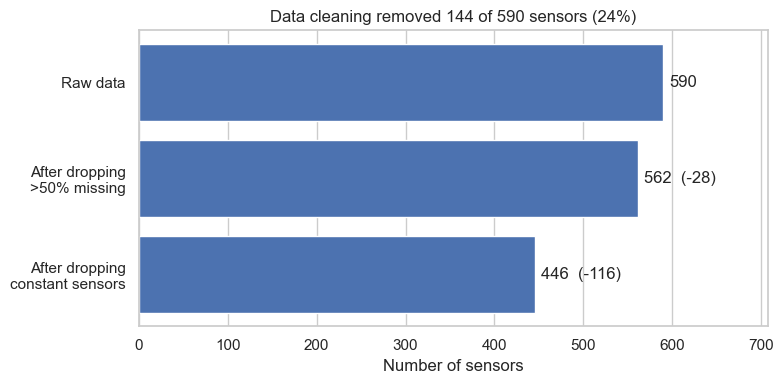

In [14]:
# cleaning funnel: number of sensors left after each step
n_start = sensor_columns.shape[1]
n_after_missing = n_start - len(high_missing_cols)
n_after_constant = remaining_sensors.shape[1]

steps = ["Raw data", "After dropping\n>50% missing", "After dropping\nconstant sensors"]
sensors_left = [n_start, n_after_missing, n_after_constant]
bar_labels = [f"{n_start}",
              f"{n_after_missing}  (-{n_start - n_after_missing})",
              f"{n_after_constant}  (-{n_after_missing - n_after_constant})"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(steps, sensors_left )
ax.invert_yaxis() 
ax.bar_label(bars, labels=bar_labels, padding=4)

n_removed = n_start - n_after_constant
ax.set_title(f"Data cleaning removed {n_removed} of {n_start} sensors ({n_removed / n_start:.0%})")
ax.set_xlabel("Number of sensors")
ax.set_xlim(0, n_start * 1.2)  
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig("../images/cleaning_summary.png", dpi=150) 
plt.show()

- `df_clean` now has 1,567 runs, 446 sensors + `timestamp` and `fail`.
- The biggest drop came from the constant sensors (116), not from the missing values (28).
- Missing values are down to ~1.56%, the rest will be median imputed inside the Pipeline.
- 33 timestamps repeat but they are different runs (different sensor values), so they are kept.

## 3. Exploratory Data Analysis

In this section, we will check the target, time trends, missing values, sensor differences between pass and fail, correlations and outliers.

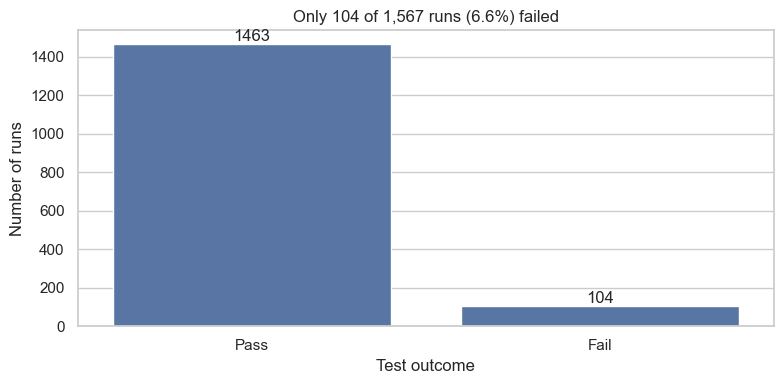

In [15]:
# class balance

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df_clean, x="fail", ax=ax)
ax.set_xticks([0, 1], ["Pass", "Fail"])
ax.bar_label(ax.containers[0])
ax.set_title("Only 104 of 1,567 runs (6.6%) failed")
ax.set_xlabel("Test outcome")
ax.set_ylabel("Number of runs")
plt.tight_layout()
plt.savefig("../images/class_balance.png", dpi=150)
plt.show()

The pass bar is about 14 times bigger than the fail bar. This is the imbalance problem from Section 1, a model can look "good" by just predicting pass every time, that's why I use PR-AUC and recall on the fail class instead of accuracy.

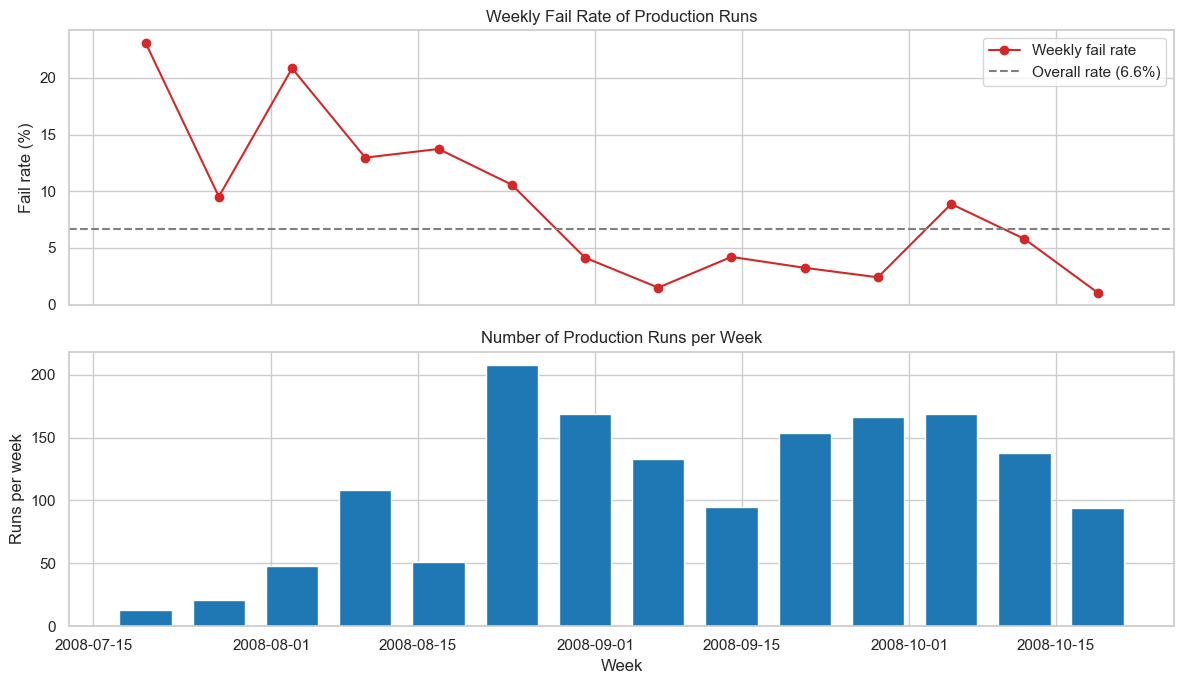

In [16]:
#Fail rate over time (line chart)

weekly = df_clean.set_index("timestamp").resample("W")["fail"]
weekly_fail_rate = weekly.mean()*100
weekly_runs = weekly.count()
overall_rate = df_clean["fail"].mean()*100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(weekly_fail_rate.index, weekly_fail_rate.values,
         marker="o", color="tab:red", label="Weekly fail rate")
ax1.axhline(overall_rate, linestyle="--", color="gray",
            label=f"Overall rate ({overall_rate:.1f}%)")
ax1.set_title("Weekly Fail Rate of Production Runs")
ax1.set_ylabel("Fail rate (%)")
ax1.legend()

ax2.bar(weekly_runs.index, weekly_runs.values, width=5, color="tab:blue")
ax2.set_title("Number of Production Runs per Week")
ax2.set_ylabel("Runs per week")
ax2.set_xlabel("Week")

plt.tight_layout()
plt.savefig("../images/fail_rate_over_time.png", dpi=150)
plt.show()

The fail rate is not constant over time. In July and August it is mostly above average (10–23% per week). From the end of August it drops to about 1–4% and stays low, apart from a small bump in early October (~9%). The first two weeks have very few runs (13 and 21), so their high rates are noisy.

From a process point of view this looks like a change around the end of August, such as tool maintenance, a recipe tune or a process change. It could also be a change in how runs were tested or labeled. The data is anonymized, so I can't confirm either.

**Impact on modeling:** if failures cluster in one period, the sensor–failure relationship may shift over time (concept drift), and a random split mixes the two periods. For the baseline I use a stratified random split. In the final report I'll also test a time-based split (train on earlier runs, test on later ones) to check that the model holds up on future production.

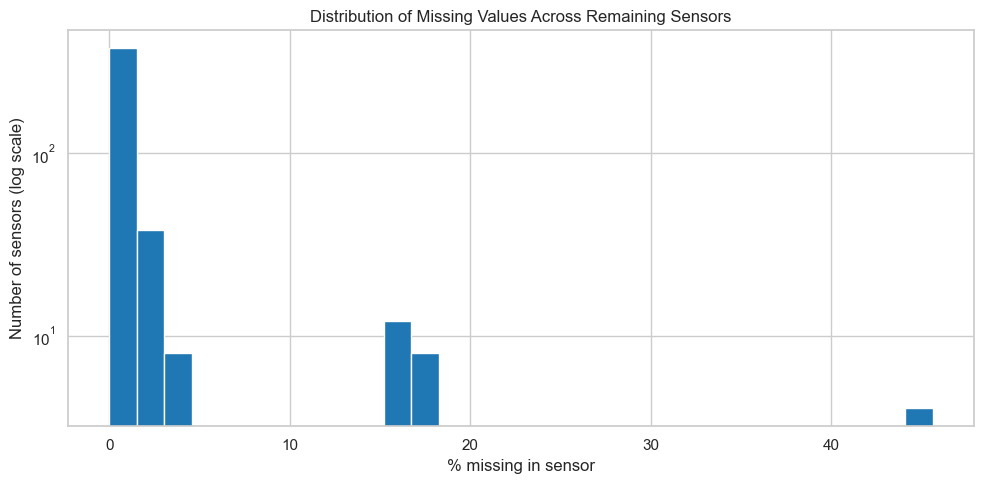

In [17]:
#missing values per sensor

missing_pct = remaining_missing * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(missing_pct, bins=30, color="tab:blue", edgecolor="white")
ax.set_yscale("log")   # the 0% bar dominates, so log scale keeps the small bars visible
ax.set_title("Distribution of Missing Values Across Remaining Sensors")
ax.set_xlabel("% missing in sensor")
ax.set_ylabel("Number of sensors (log scale)")
plt.tight_layout()
plt.savefig("../images/missing_values_per_sensor.png", dpi=150)
plt.show()

Almost all sensors are missing less than 5% of their values. But there are 2 clear groups: about 20 sensors missing ~15–18%, and a few sensors missing ~45%. Sensors that miss the same amount are probably from the same tool or measurement step that was not recorded on some runs. The median imputation should be fine for the small gaps, the ~45% group is the most uncertain one.

Top 10 sensors by |correlation| with failure:
sensor_59     0.156
sensor_103    0.151
sensor_510    0.132
sensor_348    0.130
sensor_431    0.121
sensor_434    0.112
sensor_430    0.110
sensor_435    0.109
sensor_21     0.108
sensor_28     0.107
dtype: float64


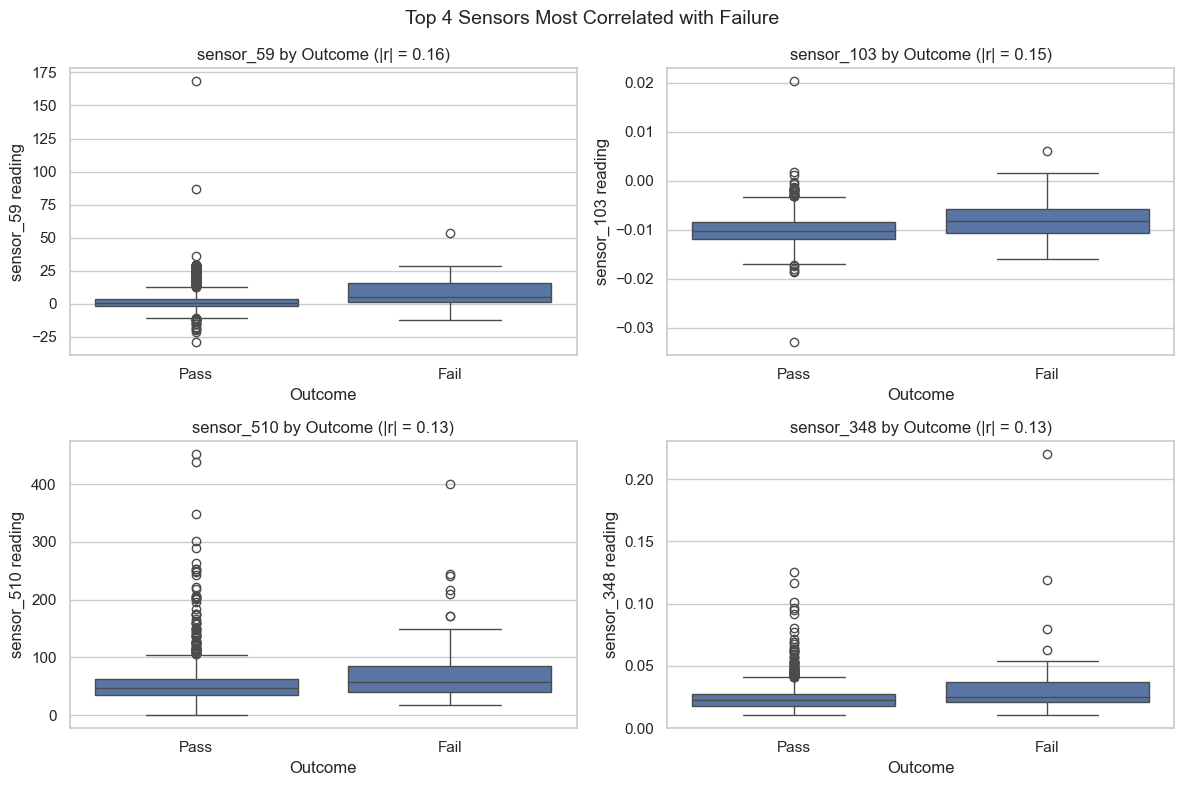

In [18]:
#which sensors differ between pass and fail 

sensors_only = df_clean.drop(columns=["timestamp", "fail"])
sensor_fail_corr = (sensors_only.corrwith(df_clean["fail"])
                    .abs()
                    .sort_values(ascending=False))

print("Top 10 sensors by |correlation| with failure:")
print(sensor_fail_corr.head(10).round(3))

top_sensors = sensor_fail_corr.head(4).index

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, sensor in zip(axes.flat, top_sensors):
    sns.boxplot(data=df_clean, x="fail", y=sensor, ax=ax)
    ax.set_title(f"{sensor} by Outcome (|r| = {sensor_fail_corr[sensor]:.2f})")
    ax.set_xlabel("Outcome")
    ax.set_xticks([0, 1], ["Pass", "Fail"])
    ax.set_ylabel(f"{sensor} reading")

fig.suptitle("Top 4 Sensors Most Correlated with Failure", fontsize=14)
plt.tight_layout()
plt.savefig("../images/top4_sensors_boxplots.png", dpi=150)
plt.show()

The strongest sensors only have |r| of about 0.11–0.16 with failure, which is weak. In the box plots the failing runs tend to have a bit higher median and wider spread (most visible for sensor_59 and sensor_103), but the pass and fail boxes still overlap a lot. So no single sensor can separate pass from fail, the model will need to combine many weak signals.

Note: this correlation uses the label on the full dataset, so it is only for exploration. I don't use it to select features for the model, because that would leak information from the test set.

In [19]:
def iqr_range(x):
    return x.quantile(0.75) - x.quantile(0.25)

def value_range(x):
    return x.max() - x.min()

# Summary statistics of the top 4 sensors, pass vs. fail
stats_table = (df_clean.groupby("fail")[list(top_sensors)]
               .agg(["mean", "std", iqr_range, "min", "max", value_range])
               .T                                   # sensors as rows, pass/fail as columns
               .round(3)
               .rename(columns={0: "Pass", 1: "Fail"})
               .rename_axis(index=["Sensor", "Statistic"], columns=None))
stats_table

Pass     Fail
Sensor     Statistic                    
sensor_59  mean           2.563    8.515
           std            9.313   10.802
           iqr_range      5.868   14.416
           min          -28.988  -12.153
           max          168.146   53.682
           value_range  197.134   65.834
sensor_103 mean          -0.010   -0.008
           std            0.003    0.003
           iqr_range      0.004    0.005
           min           -0.033   -0.016
           max            0.020    0.006
           value_range    0.053    0.022
sensor_510 mean          54.441   74.348
           std           35.770   55.337
           iqr_range     27.906   44.184
           min            0.000   18.006
           max          451.485  400.000
           value_range  451.485  381.994
sensor_348 mean           0.024    0.030
           std            0.010    0.024
           iqr_range      0.009    0.016
           min            0.010    0.010
           max            0.125    0.220
           value_range    0.115    0.210

Here's what the numbers show:

* All 4 sensors have a higher mean for failing runs, for example sensor_59 is 8.5 vs 2.6 and sensor_510 is 74 vs 54.
* The failing runs have a wider spread: the IQR is bigger for every sensor (sensor_59: 14.4 vs 5.9). Fails are more variable, not just shifted.
* The pass group has the most extreme maximums (sensor_59: 168, sensor_510: 451). There are 14× more pass runs, so they cover a wider range. Extreme values alone don't mean a fail.

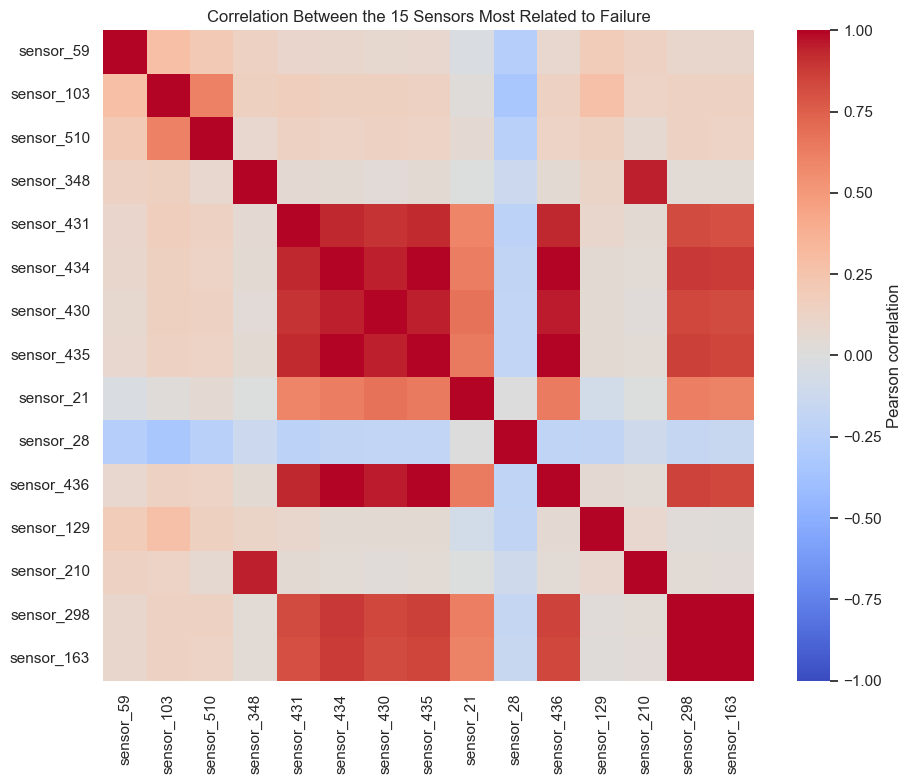

In [20]:
# correlation between the top 15 sensors (446 x 446 would be unreadable)
top15_sensors = sensor_fail_corr.head(15).index
corr_matrix = df_clean[top15_sensors].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            annot=False, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation Between the 15 Sensors Most Related to Failure")
plt.tight_layout()
plt.savefig("../images/top15_correlation_heatmap.png", dpi=150)
plt.show()

There are clear blocks of sensors that move together:
- sensor_430, 431, 434, 435 and 436 are almost perfectly correlated with each other (r ≈ 0.9–1.0),
- sensor_298 and sensor_163 are ~1.0,
- sensor_348 and sensor_210 are also very high.

These sensors probably measure the same thing (or the same signal at different points), so they are redundant. Keeping all of them adds features without adding information, and it can make logistic regression coefficients unstable. In Section 4 I will remove one of each highly correlated pair (|r| > 0.95).

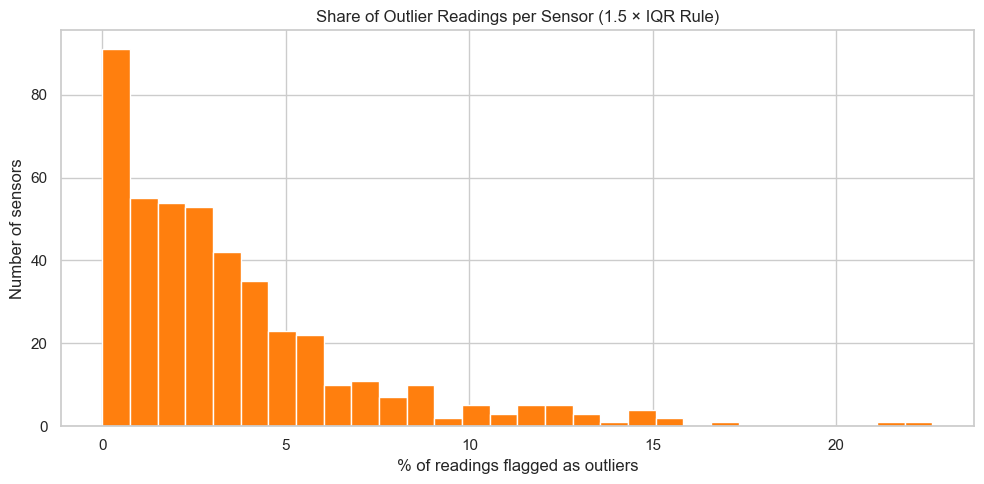

Overall share of readings that are outliers: 3.45%
Sensors with more than 10% outliers: 27
Runs with at least one outlier reading: 1566 of 1567


In [21]:
# outlier analysis with the 1.5 x IQR rule, per sensor
q1 = sensors_only.quantile(0.25)
q3 = sensors_only.quantile(0.75)
iqr = q3 - q1

outlier_mask = (sensors_only < q1 - 1.5 * iqr) | (sensors_only > q3 + 1.5 * iqr)

# divide by the non-missing count, so missing values don't lower the %
outlier_pct_per_sensor = outlier_mask.sum() / sensors_only.notna().sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(outlier_pct_per_sensor, bins=30, color="tab:orange", edgecolor="white")
ax.set_title("Share of Outlier Readings per Sensor (1.5 × IQR Rule)")
ax.set_xlabel("% of readings flagged as outliers")
ax.set_ylabel("Number of sensors")
plt.tight_layout()
plt.savefig("../images/outliers_per_sensor.png", dpi=150)
plt.show()

overall_outlier_pct = outlier_mask.sum().sum() / sensors_only.notna().sum().sum() * 100
n_sensors_over_10 = (outlier_pct_per_sensor > 10).sum()
n_runs_with_outlier = outlier_mask.any(axis=1).sum()

print(f"Overall share of readings that are outliers: {overall_outlier_pct:.2f}%")
print(f"Sensors with more than 10% outliers: {n_sensors_over_10}")
print(f"Runs with at least one outlier reading: {n_runs_with_outlier} of {len(sensors_only)}")

About 3.45% of all readings are outliers by the IQR rule. Most sensors have less than 5% outliers, but 27 sensors have more than 10% (some up to ~22%).

The important number is the last one: **1,566 of 1,567 runs have at least one outlier reading.** So removing outlier rows is not an option, it would delete basically the whole dataset.

**Decision: keep the outliers.** Reasons:
1. In process data an "outlier" is often a real excursion (a tool drifting, a bad step), and that is exactly the kind of thing that causes a fail. Removing them could remove the signal we want to find.
2. With 446 sensors, almost every run is unusual on at least one of them, which is normal.
3. To reduce their effect I use the **median** for imputation (not pulled by outliers) and scale the features with StandardScaler before the model. A RobustScaler (scales with median and IQR) is an option to try in the final report.

### Key observations (Section 3)

- **Imbalance:** only 6.6% of runs fail, so accuracy is not a useful metric. PR-AUC and recall on the fail class will be used.
- **Time trend:** the fail rate was high in Jul–Aug (10–23% per week) and dropped to ~1–4% from September. Something in the process probably changed, and the model has to deal with this shift.
- **Weak single signals:** the best sensor has only |r| ≈ 0.16 with failure, no single sensor explains the fails, so a multivariate model is needed.
- **Redundant sensors:** there are groups of sensors with r ≈ 1.0, these will be reduced in Section 4.
- **Outliers:** almost every run has some outlier reading, they are kept because they may be the real excursions behind the fails.

## 4. Feature Engineering

In this section I extract time features from the timestamp, remove sensors that are almost copies of each other, and use PCA to see how much the sensor data can be compressed.

            timestamp  hour  day_of_week  days_since_start
0 2008-07-19 11:55:00    11            5                 0
1 2008-07-19 12:32:00    12            5                 0
2 2008-07-19 13:17:00    13            5                 0
3 2008-07-19 14:43:00    14            5                 0
4 2008-07-19 15:22:00    15            5                 0


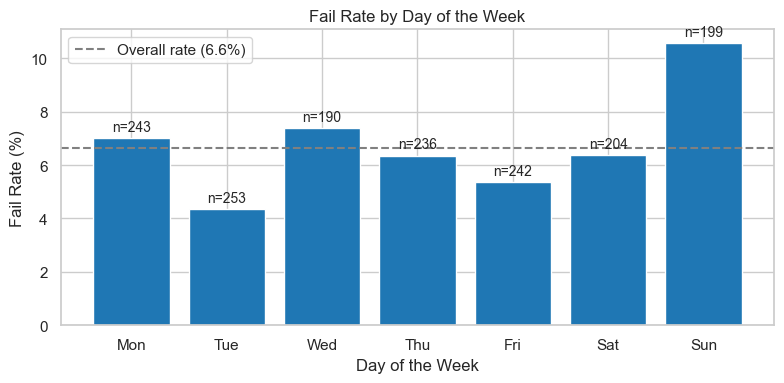

In [22]:
df_clean["hour"] = df_clean["timestamp"].dt.hour
df_clean["day_of_week"] = df_clean["timestamp"].dt.dayofweek 
df_clean["days_since_start"] = (df_clean["timestamp"] - df_clean["timestamp"].min()).dt.days

print(df_clean[["timestamp", "hour", "day_of_week", "days_since_start"]].head())

fig, ax = plt.subplots(figsize=(8, 4))
fail_rate_by_day = (df_clean.groupby("day_of_week")["fail"].mean() * 100).reindex(range(7))
runs_by_day = df_clean["day_of_week"].value_counts().reindex(range(7), fill_value=0)
overall_rate = df_clean["fail"].mean() * 100

bars = ax.bar(range(7), fail_rate_by_day.values, color="tab:blue")
ax.bar_label(bars, labels=[f"n={n}" for n in runs_by_day], padding=3, fontsize=10)
ax.axhline(overall_rate, linestyle="--", color="gray", label=f"Overall rate ({overall_rate:.1f}%)")
ax.set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_title("Fail Rate by Day of the Week")
ax.set_ylabel("Fail Rate (%)")
ax.set_xlabel("Day of the Week")
ax.legend()
plt.tight_layout()
plt.savefig("../images/fail_rate_by_day.png", dpi=150)
plt.show()

I made 3 new features from the timestamp: `hour`, `day_of_week` and `days_since_start`.

The day of week effect is small. Most days are between ~4% and 7%, only Sunday is higher (~10.6%). This could be a weekend staffing thing, but with only ~200 runs per day it is weak evidence. The hour of the day shows almost no difference (6–7% in every 6-hour block), so I didn't plot it.

**About `days_since_start`:** in Section 3 the fail rate dropped over time, so this feature will look "predictive". But it can't help for future production, every new run has a bigger value than anything the model saw in training, so it only learns "early = more fails". That's why I **keep `hour` and `day_of_week` for the model and leave `days_since_start` out**.

In [23]:
# remove highly correlated sensors (|r| > 0.95)
# use only the sensor columns, so the new time features are not part of the correlation
sensor_cols = [col for col in df_clean.columns if col.startswith("sensor_")]
corr_abs = df_clean[sensor_cols].corr().abs()

# upper triangle only, so each pair is checked once and only one sensor of the pair is dropped
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape, dtype=bool), k=1))
high_corr_cols = [col for col in upper.columns if (upper[col] > 0.95).any()]

n_sensors_before = len(sensor_cols)
df_clean = df_clean.drop(columns=high_corr_cols)
n_sensors_after = sum(col.startswith("sensor_") for col in df_clean.columns)

print(f"highly correlated sensores dropped (|r|>0.95): {len(high_corr_cols)}")
print(f"Sensors: {n_sensors_before} --> {n_sensors_after} ")

highly correlated sensores dropped (|r|>0.95): 174
Sensors: 446 --> 272 


174 sensors were almost a copy of another sensor (|r| > 0.95), which fits with the correlated groups in the heatmap of Section 3. After removing them, 272 sensors are left.

Removing them makes the model simpler and the logistic regression coefficients more stable, without really losing information, because the sensor that is kept carries the same signal. Like the cleaning in Section 2, this step does not use the `fail` label, so it is ok to do it before the train/test split.

Components needed for 80% of variance: 100 of 272
Components needed for 90% of variance: 137 of 272
Components needed for 95% of variance: 166 of 272


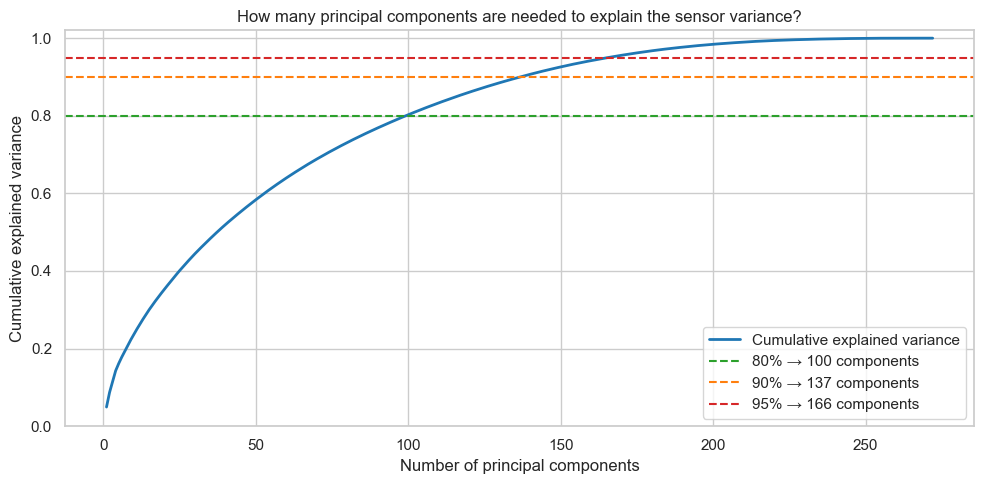

In [24]:
sensor_cols = [col for col in df_clean.columns if col.startswith("sensor_")]
X_sensors = df_clean[sensor_cols]

# PCA needs no missing values and scaled data (fit on all data here, only for exploration)
X_imputed = SimpleImputer(strategy="median").fit_transform(X_sensors)
X_scaled = StandardScaler().fit_transform(X_imputed)

# PCA and cumulative explained variance
pca = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components = np.arange(1, len(cum_var) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_components, cum_var, color="tab:blue", linewidth=2,
        label="Cumulative explained variance")

for threshold, color in zip([0.80, 0.90, 0.95], ["tab:green", "tab:orange", "tab:red"]):
    n_needed = np.argmax(cum_var >= threshold) + 1
    ax.axhline(threshold, linestyle="--", color=color,
               label=f"{threshold:.0%} → {n_needed} components")
    print(f"Components needed for {threshold:.0%} of variance: {n_needed} of {len(sensor_cols)}")

ax.set_title("How many principal components are needed to explain the sensor variance?")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/pca_explained_variance.png", dpi=150)
plt.show()

The curve rises slowly: the first component explains only ~5% of the variance, and we need 100 components for 80%, 137 for 90% and 166 for 95%. So the variance is spread over many directions, there is no small set of "main signals" in the sensors. This fits with Section 3, many weak sensors and no strong one.

PCA could reduce the 272 sensors to ~137 components and still keep 90% of the variance. But for the baseline I use the **272 sensors directly**, because they are interpretable and objective #3 is to find which sensors matter. With PCA components that is not possible. PCA stays an option to compare in the final report.

Note: here PCA is fit on all the data, only for exploration. If I use it in a model it will be a step inside the Pipeline, so it is fit on the training data only.

X shape: (1567, 274)
y shape: (1567,)
missing values still in X: 1.67%


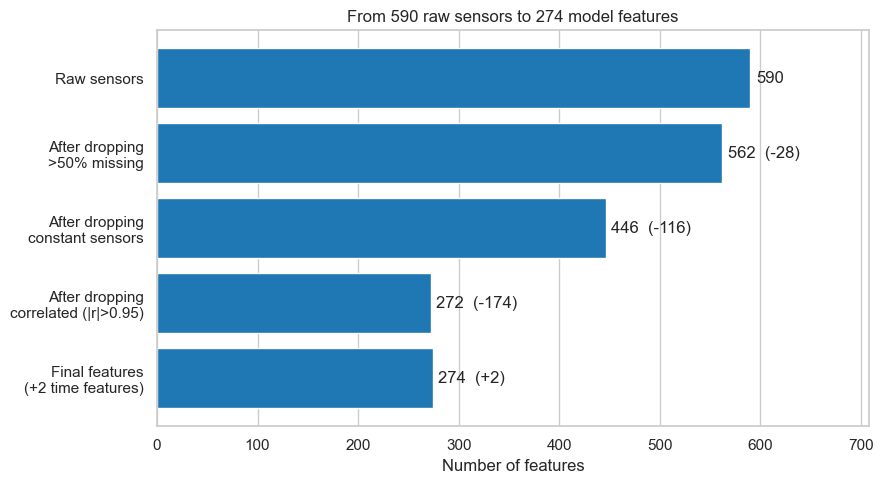

In [25]:
# final feature set for the model: remaining sensors + 2 time features
# (days_since_start is left out on purpose, see above)
time_features = ["hour", "day_of_week"]
feature_cols = sensor_cols + time_features

X = df_clean[feature_cols]
y = df_clean["fail"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"missing values still in X: {X.isnull().mean().mean()*100:.2f}%")

# full funnel: from the raw sensors to the final features
steps = ["Raw sensors", "After dropping\n>50% missing", "After dropping\nconstant sensors",
         "After dropping\ncorrelated (|r|>0.95)", "Final features\n(+2 time features)"]
counts = [n_start, n_after_missing, n_after_constant, n_sensors_after, X.shape[1]]
bar_labels = [f"{counts[0]}"] + [f"{c}  ({c - prev:+d})" for prev, c in zip(counts[:-1], counts[1:])]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(steps, counts, color="tab:blue")
ax.invert_yaxis()   # first step on top
ax.bar_label(bars, labels=bar_labels, padding=4)
ax.set_title(f"From {n_start} raw sensors to {X.shape[1]} model features")
ax.set_xlabel("Number of features")
ax.set_xlim(0, n_start * 1.2)   # room for the labels
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("../images/feature_reduction_summary.png", dpi=150)
plt.show()

The model input `X` now has 1,567 runs and 274 features (272 sensors + `hour` + `day_of_week`), and `y` is the `fail` column (0 = pass, 1 = fail).

The plot shows the full path from the raw data: more than half of the original 590 sensors were removed. Most of them were constant (116) or almost a copy of another sensor (174), only 28 were removed for missing values. So the dataset had a lot of redundancy, and the model now works with less than half the features without losing much information.

`X` still has a few missing values, these are not filled here. They will be median-imputed inside the Pipeline in Section 5, after the train/test split.

### Key observations (Section 4)

- **Time features:** `hour` and `day_of_week` added. The effects are small (Sunday ~10.6% vs ~6.6% overall). `days_since_start` is left out on purpose because it can't generalize to future runs.
- **Redundant sensors:** 174 sensors with |r| > 0.95 removed, 446 → 272 sensors.
- **PCA:** the variance is spread out, ~137 components are needed for 90%. Kept as an option for the final report, the baseline uses the original sensors.
- **Final feature set:** 272 sensors + 2 time features = 274 features. They still have some missing values, these will be median-imputed inside the Pipeline in Section 5.

## 5. Baseline Model

In this section I build a first, simple model to see if the sensors can predict a fail at all. I compare a "dummy" model that always predicts pass with a logistic regression, and evaluate both with PR-AUC and recall on the fail class. The goal here is not the best model, but a reference point for the final report.

In [26]:
# 80/20 split, stratified so both sets keep the same ~6.6% fail rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, fails: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Test:  {X_test.shape}, fails: {y_test.sum()} ({y_test.mean():.1%})")

Train: (1253, 274), fails: 83 (6.6%)
Test:  (314, 274), fails: 21 (6.7%)


I split the data 80/20 into train and test. With `stratify=y` both sets keep the same fail rate (~6.6%), without it a random split could put too few fails in the test set. The test set is only used at the end, all the learning (imputation, scaling, model) happens on the training set.

Note: the test set has only **21 fails**, so every fail that is caught or missed changes the recall by ~5%. The results will be noisy, that's why I also use cross-validation below.

### Evaluation metric

**Primary metric: PR-AUC (average precision)**

The model gives each run a probability of failing. PR-AUC checks how well the model ranks the failing runs above the passing runs, over all possible thresholds. I chose it because:
- it focuses on the fail class (the rare one we care about) and is not inflated by the many easy passes,
- it does not depend on one fixed threshold, the threshold can be tuned later depending on how many false alarms the fab can accept,
- it has a clear "no skill" reference: a model that guesses randomly scores about the fail rate, **~0.067**. So anything clearly above 0.067 means the sensors carry real signal.

**Secondary metric: recall on the fail class**

Recall = share of the failing runs that the model catches. A missed fail means bad wafers continue through more process steps, which costs much more than a false alarm (an extra check by an engineer), so recall is the most important number at the chosen threshold.

**Also reported:** precision (how many of the flagged runs really fail = cost of false alarms), F1, the confusion matrix and ROC-AUC.

**Not used: accuracy.** As shown in Section 1, a model that always says "pass" already gets 93.4% accuracy while catching zero fails, so accuracy says nothing useful here.

In [27]:
# dummy baseline: ignores the sensors and always predicts the most common class (pass)
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
y_preds_dummy = dummy.predict(X_test)                 # labels (0/1) for accuracy and recall
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]     # probability of fail for PR-AUC
accuracy_dummy = accuracy_score(y_test, y_preds_dummy)
recall_dummy = recall_score(y_test, y_preds_dummy)
average_precision_dummy = average_precision_score(y_test, y_proba_dummy)

print (f"Dummy model accuracy: {accuracy_dummy:.3f}")
print (f"Dummy model recall: {recall_dummy:.3f}")
print (f"Dummy model average precision (PR-AUC): {average_precision_dummy:.3f}")

Dummy model accuracy: 0.933
Dummy model recall: 0.000
Dummy model average precision (PR-AUC): 0.067


* The dummy gets 93% accuracy while catching zero fails. That's direct proof of why accuracy was rejected in the metric cell above.
* PR-AUC 0.067 is the reference line: the logistic regression below has to beat it clearly to show the sensors contain real signal.

In [28]:
# pipeline: impute -> scale -> model, all fit on the training data only (no leakage)
lr_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # median, because of the outliers
    ("scaler", StandardScaler()),                    # sensors have very different scales
    ("classifier", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
]).fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)                # labels with the default 0.5 threshold
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]   # probability of fail

print(classification_report(y_test, y_pred_lr, target_names=["Pass", "Fail"]))

pr_auc_lr = average_precision_score(y_test, y_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"PR-AUC (average precision): {pr_auc_lr:.3f}")
print(f"ROC-AUC: {roc_auc_lr:.3f}")

# side by side comparison of the two models on the test set
results = pd.DataFrame({
    "Accuracy":  [accuracy_dummy, accuracy_score(y_test, y_pred_lr)],
    "Recall (fail)":    [recall_dummy, recall_score(y_test, y_pred_lr)],
    "Precision (fail)": [0.0, precision_score(y_test, y_pred_lr)],
    "PR-AUC":    [average_precision_dummy, pr_auc_lr],
}, index=["Dummy (always pass)", "Logistic regression"]).round(3)
results

              precision    recall  f1-score   support

        Pass       0.94      0.87      0.90       293
        Fail       0.10      0.19      0.13        21

    accuracy                           0.82       314
   macro avg       0.52      0.53      0.51       314
weighted avg       0.88      0.82      0.85       314

PR-AUC (average precision): 0.143
ROC-AUC: 0.643


,Accuracy,Recall (fail),Precision (fail),PR-AUC
Dummy (always pass),0.933,0.00,0.000,0.067
Logistic regression,0.825,0.19,0.095,0.143


The logistic regression gets a PR-AUC of **0.143**, about **2 times** the dummy (0.067), so the sensors do carry some real signal about the fails. But the recall is still low: it catches only 4 of the 21 failing runs (19%), and only ~10% of the runs it flags are real fails.

The accuracy dropped from 93% to 83% compared to the dummy. This is expected and ok: because of `class_weight="balanced"` the model now raises alarms instead of saying "pass" every time, and some of them are false alarms. That is the trade we want, a model that never flags anything is useless for catching fails.

In [29]:
# 5-fold stratified cross-validation on the training set (the whole pipeline is re-fit in each fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_pr_auc = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="average_precision")
cv_recall = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="recall")

print("PR-AUC per fold:", cv_pr_auc.round(3))
print(f"PR-AUC mean: {cv_pr_auc.mean():.3f} ± {cv_pr_auc.std():.3f}")
print("Recall per fold:", cv_recall.round(3))
print(f"Recall mean: {cv_recall.mean():.3f} ± {cv_recall.std():.3f}")

# overfitting check: score on the data the model was trained on vs. the unseen test set
y_proba_train = lr_pipe.predict_proba(X_train)[:, 1]
pr_auc_train = average_precision_score(y_train, y_proba_train)
print(f"PR-AUC train: {pr_auc_train:.3f}  vs  test: {pr_auc_lr:.3f}")

PR-AUC per fold: [0.093 0.265 0.146 0.067 0.254]
PR-AUC mean: 0.165 ± 0.081
Recall per fold: [0.118 0.412 0.235 0.188 0.438]
Recall mean: 0.278 ± 0.126
PR-AUC train: 0.914  vs  test: 0.143


- **Not a fluke:** the CV mean PR-AUC (0.165) is close to the test result (0.143), both are about 2x the no-skill level of 0.067.
- **Noisy:** the folds go from 0.067 (no better than chance) to 0.265, and recall from 12% to 44%. With only ~17 fails per fold, one more or one less caught fail changes the score a lot.
- **Strong overfitting:** PR-AUC on the training data is 0.914, on the test data only 0.143. The model almost memorized the training runs. With 274 features and only 83 fails to learn from, it has too much freedom, and what it learned does not transfer to new runs.

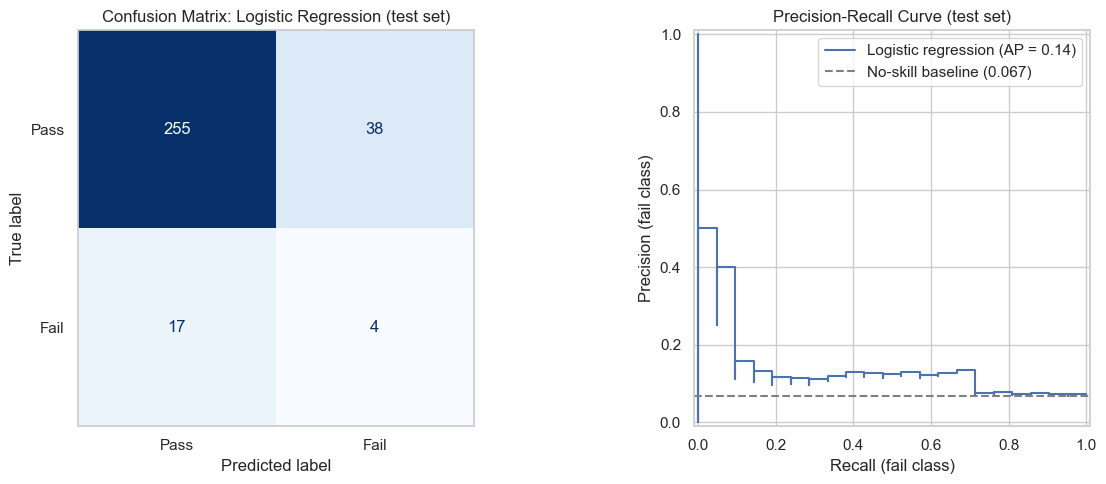

In [30]:
# confusion matrix (left) and precision-recall curve (right) on the test set
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=["Pass", "Fail"], cmap="Blues", ax=ax1, colorbar=False
)
ax1.set_title("Confusion Matrix: Logistic Regression (test set)")
ax1.grid(False)   # the seaborn grid lines cross the matrix cells

PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_lr, name="Logistic regression", ax=ax2
)
ax2.axhline(y_test.mean(), linestyle="--", color="gray",
            label=f"No-skill baseline ({y_test.mean():.3f})")
ax2.set_title("Precision-Recall Curve (test set)")
ax2.set_xlabel("Recall (fail class)")
ax2.set_ylabel("Precision (fail class)")
ax2.legend()

plt.tight_layout()
plt.savefig("../images/baseline_model_results.png", dpi=150)
plt.show()

**Confusion matrix:** of the 21 failing runs in the test set, the model caught 4 and missed 17. On the other side it flagged 38 good runs as fail (false alarms). So for every real fail it catches, an engineer would check about 9 good runs for nothing.

**PR curve:** the curve stays above the no-skill line almost everywhere, so the ranking has some value. At the very left (the runs the model is most sure about) precision is higher, up to 0.4–0.5, but as soon as we try to catch more fails, the precision drops fast to ~0.10–0.13. The default 0.5 threshold gives a recall of 0.19, a lower threshold would catch more fails but with more false alarms. Where to put the threshold is a business decision: how many false alarms can the fab handle for each fail that is caught.

### Interpretation of the baseline results

**1. Does the model beat the baseline?**
Yes, but only moderately. The PR-AUC is 0.143 on the test set and 0.165 in cross-validation, compared to 0.067 for the dummy / random guessing, so about 2 times better than chance. This answers the first part of the research question with a careful "yes": the in-line sensors do contain some information about which runs will fail.

**2. What does it mean in the fab?**
Out of 21 failing runs the model caught 4 and missed 17, and it raised 38 false alarms. In practice an engineer would have to check ~9 good runs for every real fail found, and most fails would still go through. So this baseline shows the approach can work, but it is **not good enough to use in production yet**.

**3. Why is it weak?**
The main problem is overfitting: PR-AUC 0.91 on the training data vs 0.14 on the test data. The model has 274 features but only 83 failing runs to learn from, so it finds patterns in the training data that are just noise. This fits with the EDA: no single sensor is strong (best |r| ≈ 0.16), the signal is weak and spread over many sensors, and the fail rate also changes over time.

**4. How reliable are these numbers?**
Not very precise. The PR-AUC changes from 0.07 to 0.27 between CV folds and the recall from 12% to 44%. With only ~17–21 fails in each evaluation set, one fail more or less moves the recall by ~5 points. So the results should be read as "about 2x better than chance", not as exact values.

**5. Next steps for the final report**
- **Overfitting** → tune the regularization strength `C` with GridSearchCV (stronger regularization).
- **Weak, non-linear signal** → try Random Forest, gradient boosting and SVM.
- **Low recall** → tune the decision threshold on the PR curve, to find an acceptable number of false alarms per caught fail.
- **Which sensors matter (objective 3)** → permutation importance, to give engineers a short list of sensors to monitor.
- **Time trend from Section 3** → test with a time-based split (train on earlier runs, test on later ones).

### Key observations (Section 5)

- **Accuracy is misleading:** the dummy model gets 93% accuracy but catches 0 fails.
- **Baseline result:** logistic regression reaches PR-AUC 0.14 (CV 0.17), about 2x chance, and catches 19% of the failing runs (4 of 21) with 38 false alarms.
- **Overfitting and noise:** train PR-AUC 0.91 vs test 0.14, and the scores change a lot between CV folds because there are so few fails.
- **Next:** regularization tuning, tree ensembles, threshold tuning and feature importance in the final report.